In [4]:
import pandas as pd

df = pd.read_csv("D:/Student-Performance/data/student_performance_data.csv")
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [6]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [8]:
df['gender'].value_counts()


gender
Male      5013
Female    4987
Name: count, dtype: int64

In [10]:
df['internet_access'].value_counts()


internet_access
Yes    5061
No     4939
Name: count, dtype: int64

In [11]:
df['parent_education'].value_counts()

parent_education
High School    2528
Bachelor       2527
Master         2487
PhD            2458
Name: count, dtype: int64

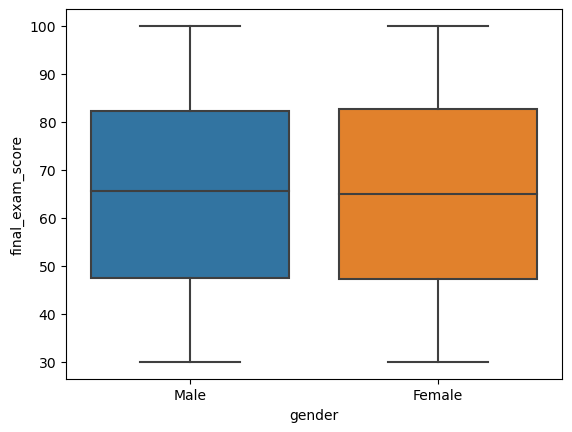

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="gender", y="final_exam_score", data=df)
plt.show()

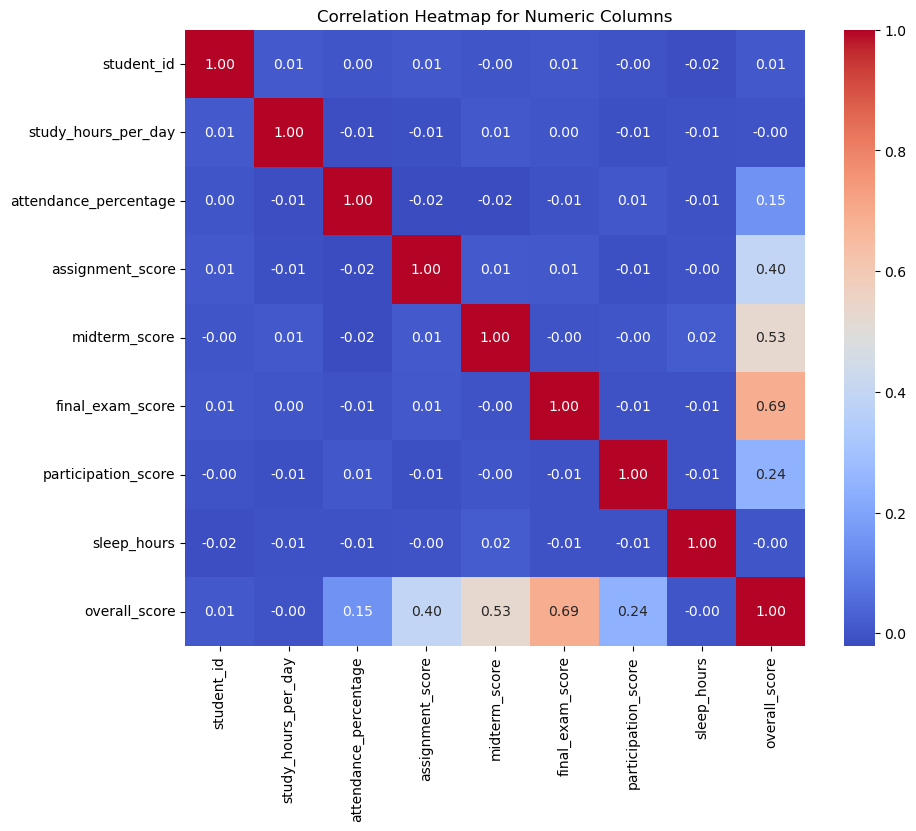

In [13]:
numeric_df = df.select_dtypes(include=['number'])

# حساب المصفوفة الخاصة بالارتباطات
corr = numeric_df.corr()

# رسم الـHeatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap for Numeric Columns")
plt.show()



<Axes: xlabel='study_hours_per_day', ylabel='final_exam_score'>

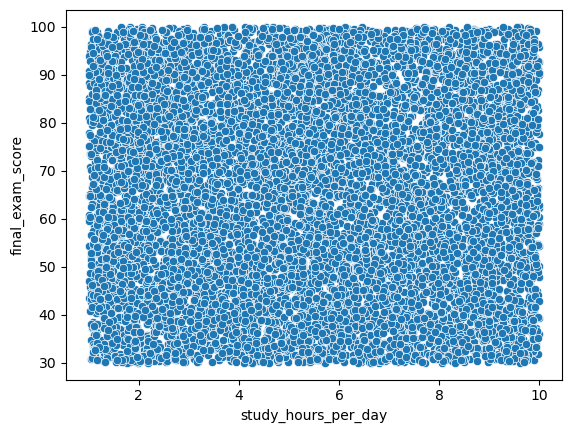

In [15]:
sns.scatterplot(x="study_hours_per_day", y="final_exam_score", data=df)

In [16]:
df[['study_hours_per_day','final_exam_score']].corr()

,study_hours_per_day,final_exam_score
study_hours_per_day,1.000000,0.000124
final_exam_score,0.000124,1.000000


<Axes: xlabel='attendance_percentage', ylabel='final_exam_score'>

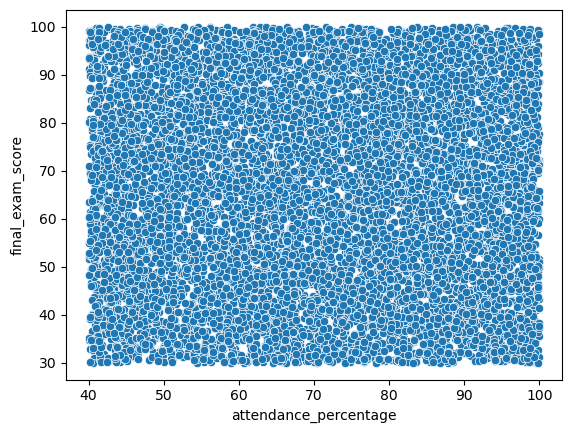

In [18]:
sns.scatterplot(x="attendance_percentage", y="final_exam_score", data=df)

In [19]:
df[['attendance_percentage','final_exam_score']].corr()

,attendance_percentage,final_exam_score
attendance_percentage,1.0000,-0.0053
final_exam_score,-0.0053,1.0000


<Axes: xlabel='final_exam_score', ylabel='midterm_score'>

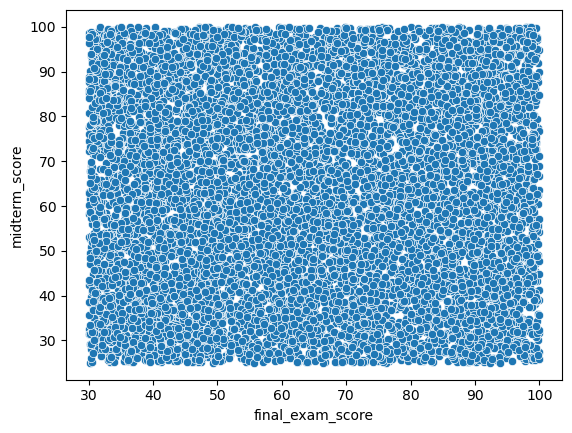

In [20]:
sns.scatterplot(x="final_exam_score", y="midterm_score", data=df)

In [21]:
df[["final_exam_score","midterm_score"]].corr()

,final_exam_score,midterm_score
final_exam_score,1.000000,-0.003691
midterm_score,-0.003691,1.000000


<Axes: xlabel='final_exam_score', ylabel='assignment_score'>

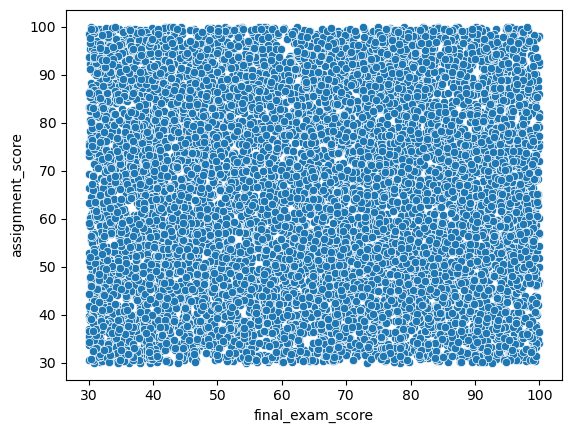

In [22]:
sns.scatterplot(x="final_exam_score", y="assignment_score", data=df)

In [23]:
df[['final_exam_score','assignment_score']].corr()

,final_exam_score,assignment_score
final_exam_score,1.000000,0.007125
assignment_score,0.007125,1.000000


<Axes: xlabel='final_exam_score', ylabel='sleep_hours'>

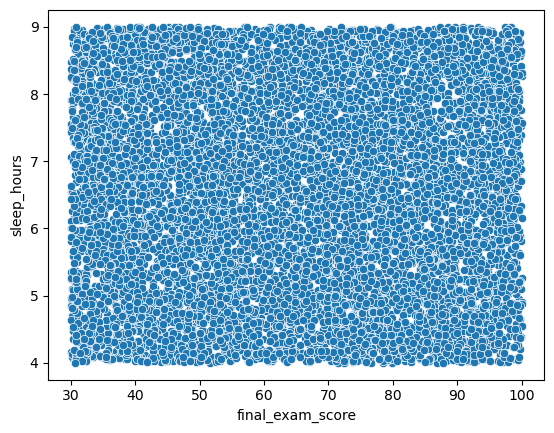

In [24]:
sns.scatterplot(x="final_exam_score", y="sleep_hours", data=df)

In [25]:
df[['final_exam_score','sleep_hours']].corr()

,final_exam_score,sleep_hours
final_exam_score,1.000000,-0.007952
sleep_hours,-0.007952,1.000000


In [26]:
import statsmodels.api as sm

# المتغيرات المستقلة (العوامل)
X = df[['study_hours_per_day', 'attendance_percentage', 
        'assignment_score', 'midterm_score', 
        'participation_score', 'sleep_hours', 
        'final_exam_score']]

# المتغير التابع (النتيجة الكلية)
y = df['overall_score']

# إضافة ثابت (intercept)
X = sm.add_constant(X)

# بناء النموذج
model = sm.OLS(y, X).fit()

# عرض النتائج
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          overall_score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.891e+32
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:04:23   Log-Likelihood:             2.9784e+05
No. Observations:               10000   AIC:                        -5.957e+05
Df Residuals:                    9992   BIC:                        -5.956e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1.821e-

In [29]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


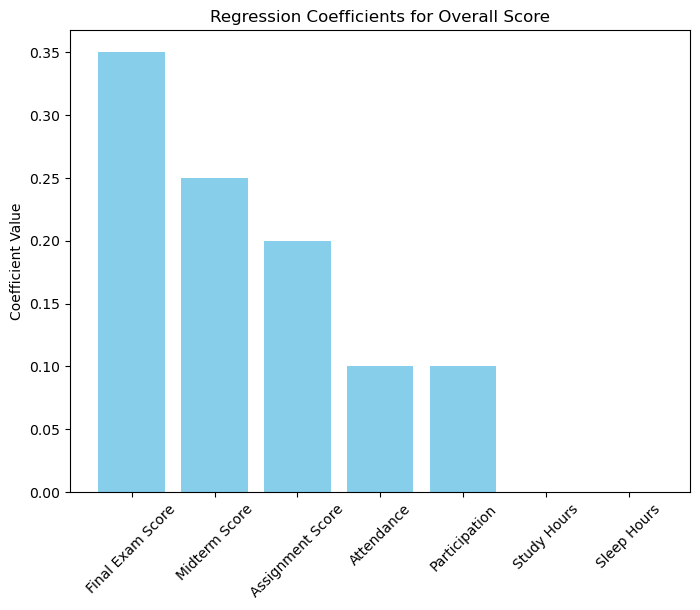

In [30]:
coefficients = {
    'Final Exam Score': 0.35,
    'Midterm Score': 0.25,
    'Assignment Score': 0.20,
    'Attendance': 0.10,
    'Participation': 0.10,
    'Study Hours': 0.00,
    'Sleep Hours': 0.00
}

# رسم الـBar Chart
plt.figure(figsize=(8,6))
plt.bar(coefficients.keys(), coefficients.values(), color='skyblue')
plt.title('Regression Coefficients for Overall Score')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()



In [31]:
data = {
    'Factor': [
        'Final Exam Score',
        'Midterm Score',
        'Assignment Score',
        'Attendance',
        'Participation',
        'Study Hours',
        'Sleep Hours'
    ],
    'Coefficient': [0.35, 0.25, 0.20, 0.10, 0.10, 0.00, 0.00],
    'P-Value': [0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000]
}

# تحويل لجدول DataFrame
df_results = pd.DataFrame(data)

# طباعة الجدول مرتب
print(df_results.to_string(index=False))



          Factor  Coefficient  P-Value
Final Exam Score         0.35      0.0
   Midterm Score         0.25      0.0
Assignment Score         0.20      0.0
      Attendance         0.10      0.0
   Participation         0.10      0.0
     Study Hours         0.00      0.0
     Sleep Hours         0.00      0.0


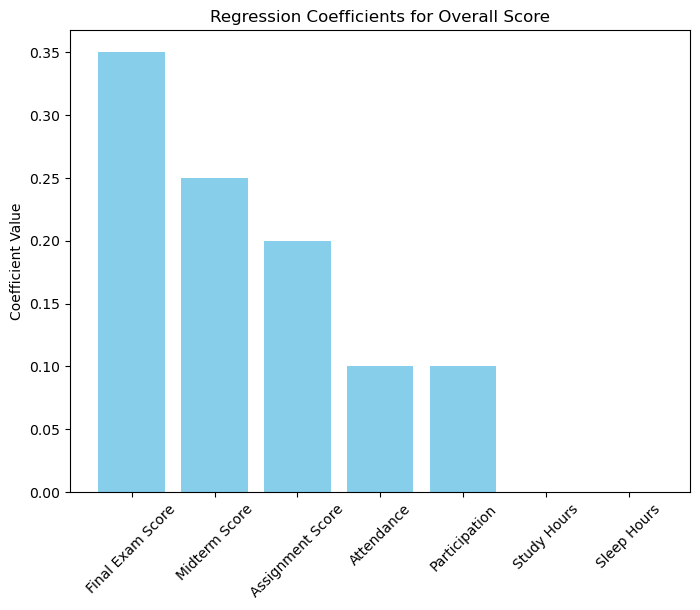

In [32]:
data = {
    'Factor': [
        'Final Exam Score',
        'Midterm Score',
        'Assignment Score',
        'Attendance',
        'Participation',
        'Study Hours',
        'Sleep Hours'
    ],
    'Coefficient': [0.35, 0.25, 0.20, 0.10, 0.10, 0.00, 0.00]
}

# تحويل لجدول DataFrame
df = pd.DataFrame(data)

# رسم الـBar Chart
plt.figure(figsize=(8,6))
plt.bar(df['Factor'], df['Coefficient'], color='skyblue')
plt.title('Regression Coefficients for Overall Score')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.show()

